## question 1
**generate and plot for following signals**
- unit step function
- unit impulse function
- ramp function
- exponential signal (decaying and growing)
- sinusoidal signal

In [7]:
import numpy as np

#defining time index(discrete)
n=np.arange(-10,10,1)

# (a) unit step function
u=np.where(n>= 0,1,0)

# (b) unit impulse function
delta = np.where(n== 0,1,0)

# (c) ramp function
ramp = np.where(n>= 0, n, 0)

# (d) exponential signal (decaying and growing)
a_decay = 0.8
a_grow = 1.2
exp_decay = np.power(a_decay, np.where(n>= 0, n, 0))
exp_grow = np.power(a_grow, np.where(n>=0, n, 0))

# (e) sinusoidal signal
A = 1
omega = np.pi/4 #frequency
phi = 0
sinusoid = A*np.sin(omega * n + phi)

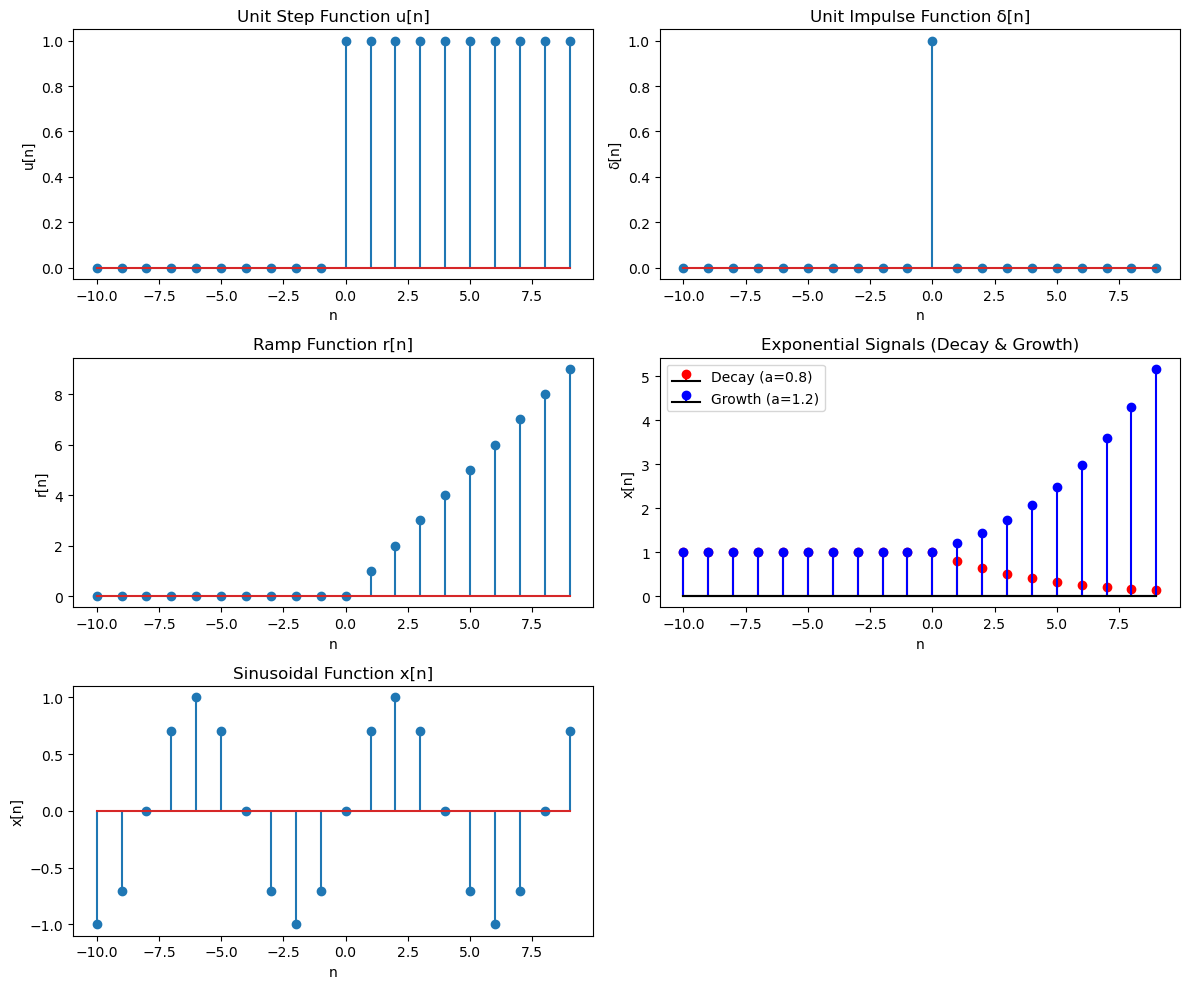

In [15]:
import matplotlib.pyplot as plt

#plotting
plt.figure(figsize=(12,10))

#(a) unit step function
plt.subplot(3,2,1)
plt.stem(n, u)
plt.title("Unit Step Function u[n]")
plt.xlabel("n"); plt.ylabel("u[n]")

#(b) unit impulse function
plt.subplot(3,2,2)
plt.stem(n, delta)
plt.title("Unit Impulse Function δ[n]")
plt.xlabel("n"); plt.ylabel("δ[n]")

#(c) ramp function
plt.subplot(3,2,3)
plt.stem(n, ramp)
plt.title("Ramp Function r[n]")
plt.xlabel("n"); plt.ylabel("r[n]")

#(d) exponential signals (decay and growth)
plt.subplot(3,2,4)
plt.stem(n, exp_decay, linefmt='r-', markerfmt='ro', basefmt='k')
plt.stem(n, exp_grow, linefmt='b-', markerfmt='bo', basefmt='k')
plt.title("Exponential Signals (Decay & Growth)")
plt.xlabel("n"); plt.ylabel("x[n]")
plt.legend(["Decay (a=0.8)", "Growth (a=1.2)"])

#(e) sinusoidal signal
plt.subplot(3,2,5)
plt.stem(n, sinusoid)
plt.title("Sinusoidal Function x[n]")
plt.xlabel("n"); plt.ylabel("x[n]")

plt.tight_layout()
plt.show()

## question 2
- visualise effects of sampling and reconstruct a continuous time-signal
- generate continuous sinusoidal signal
- sample signal at different rates (above nyquist rate, and below nyquist)
- reconstruct the sampled signal and observe the aliasing effect when under-sampled
- plot the continuous signal, sampled points, and the reconstructed signal

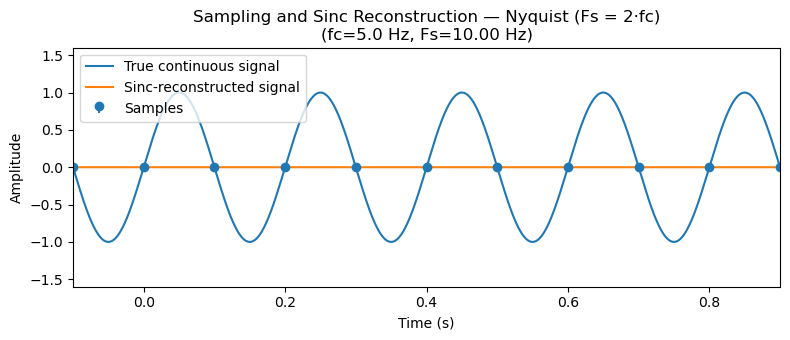

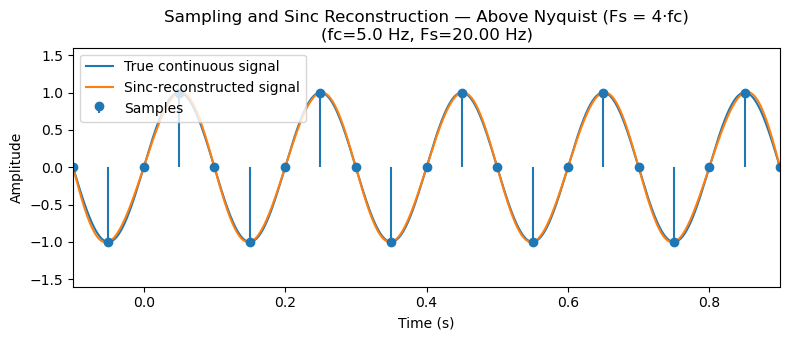

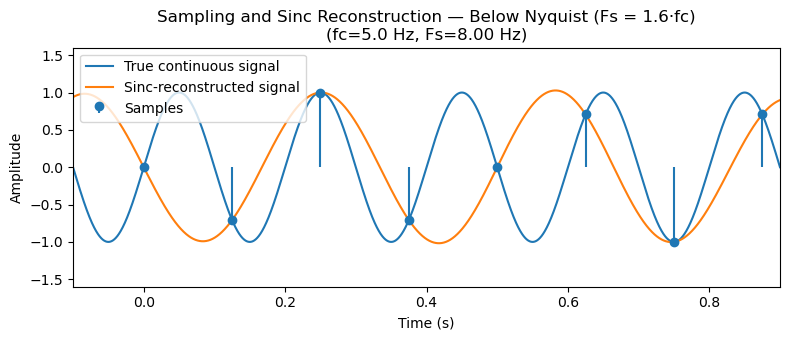

In [23]:
import numpy as np
import matplotlib.pyplot as plt 

#continuous-time (ground truth) sinusoid parameters
A=1.0
fc=5.0 #signal frequency in Hz
omega = 2 * np.pi * fc
phi = 0.0
t_start, t_end = -0.1, 0.9
t_cont = np.linspace(t_start, t_end, 4000) #dense time axis for "continuous" signal
x_cont = A * np.sin(omega * t_cont + phi)

#sampling rates to demonstrate (nyquist above and below)
Fs_list = [2*fc, 4*fc, 1.6*fc]
labels = ["Nyquist (Fs = 2·fc)", "Above Nyquist (Fs = 4·fc)", "Below Nyquist (Fs = 1.6·fc)"]

def sinc_reconstruct(t_eval, t_samples, x_samples, Ts):
    """ Whittaker-Shannon (ideal) reconstruction using sinc interpolation
        t_eval: points where we want reconstructed signal
        t_samples: sample time instants(1D array)
        x_samples: sampled values (1D array)
        Ts: sampling period
    """
    tau = (t_eval[:, None] - t_samples[None, :]) / Ts
    sinc_matrix = np.sinc(tau)
    x_rec = sinc_matrix.dot(x_samples)
    return x_rec

for Fs, lab in zip(Fs_list, labels):
    Ts = 1.0 / Fs
    n_min = int(np.floor(t_start * Fs)) - 1
    n_max = int(np.ceil(t_end * Fs)) + 1
    n = np.arange(n_min, n_max + 1)
    t_samp = n *Ts
    x_samp = A * np.sin(2 * np.pi * fc * t_samp + phi)

#reconstruct on dense grid using ideal sinc interpolation
    x_rec = sinc_reconstruct(t_cont, t_samp, x_samp, Ts)

#plot (one distinct figure per sampling rate)
    plt.figure(figsize=(8, 3.5))
    plt.plot(t_cont, x_cont) #continuous-ground truth
    plt.plot(t_cont, x_rec)  #reconstructed from samples
    plt.stem(t_samp, x_samp, basefmt=" ", markerfmt="o")  # sampled points
    plt.title(f"Sampling and Sinc Reconstruction — {lab}\n(fc={fc} Hz, Fs={Fs:.2f} Hz)")
    plt.xlabel("Time (s)"); plt.ylabel("Amplitude")
    plt.xlim(t_start, t_end)
    plt.ylim(-1.6, 1.6)
    plt.legend(["True continuous signal", "Sinc-reconstructed signal", "Samples"])
    plt.tight_layout()

plt.show()

## question 3
- generate and plot a sinusoidal signal with:
- 
amplitude = 1,
frequency = 5 hz,
duration = 1 second
- plot both continuous and discrete versions of the signal

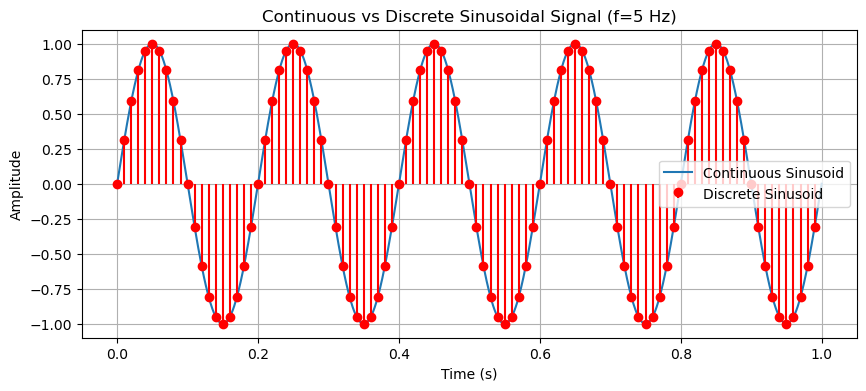

In [29]:
import numpy as np
import matplotlib.pyplot as plt

#parameters
A = 1
f = 5  #Hz
duration = 1  #sec
fs = 100  #sampling frequency for discrete

#time axis
t_cont = np.linspace(0, duration, 1000)   #high resolution for "continuous"
t_disc = np.arange(0, duration, 1/fs)

#signals
x_cont = A * np.sin(2*np.pi*f*t_cont)
x_disc = A * np.sin(2*np.pi*f*t_disc)

#plot
plt.figure(figsize=(10,4))
plt.plot(t_cont, x_cont, label="Continuous Sinusoid")
plt.stem(t_disc, x_disc, linefmt='r-', markerfmt='ro', basefmt=" ", label="Discrete Sinusoid")
plt.xlabel("Time (s)"); plt.ylabel("Amplitude")
plt.title("Continuous vs Discrete Sinusoidal Signal (f=5 Hz)")
plt.legend(); plt.grid(True)
plt.show()

## question 4
- demonstrate effects of time shifting and time scaling on a signal by
- generating a unit step function
- perform time shifting (delaying or advancing the signal)
- perform time scaling (compressing or expanding the signal)
- plot the original and transformed signals


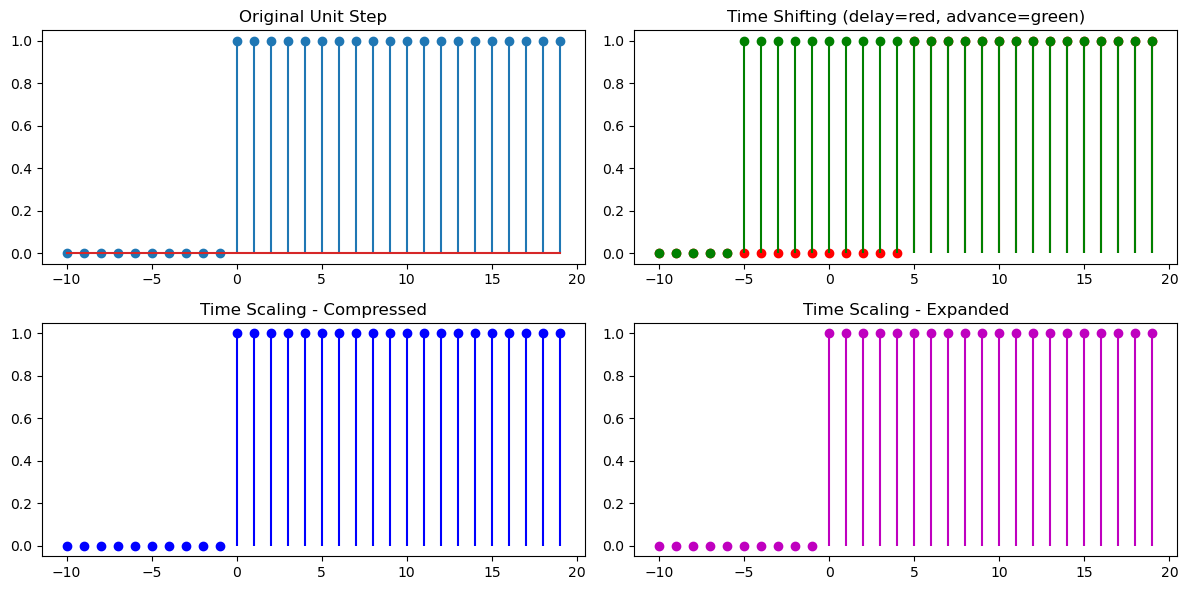

In [32]:
#time axis
n = np.arange(-10, 20)
u = np.where(n >= 0, 1, 0)  #unit step

#time shifting
u_delay = np.where(n-5 >= 0, 1, 0)   #delayed by 5
u_advance = np.where(n+5 >= 0, 1, 0) #advanced by 5

#time scaling
u_compress = np.where((n//2) >= 0, 1, 0)  #compressed
u_expand = np.where((n*2) >= 0, 1, 0)     #expanded

#plot
plt.figure(figsize=(12,6))

plt.subplot(2,2,1)
plt.stem(n, u); plt.title("Original Unit Step")

plt.subplot(2,2,2)
plt.stem(n, u_delay, linefmt='r-', markerfmt='ro', basefmt=" "); 
plt.stem(n, u_advance, linefmt='g-', markerfmt='go', basefmt=" ");
plt.title("Time Shifting (delay=red, advance=green)")

plt.subplot(2,2,3)
plt.stem(n, u_compress, linefmt='b-', markerfmt='bo', basefmt=" ")
plt.title("Time Scaling - Compressed")

plt.subplot(2,2,4)
plt.stem(n, u_expand, linefmt='m-', markerfmt='mo', basefmt=" ")
plt.title("Time Scaling - Expanded")

plt.tight_layout()
plt.show()

## question 5
- generate two sinusoidal signals with different frequencies and amplitudes
- add the signals together and plot the result
- scale one of the signals and observe the effect

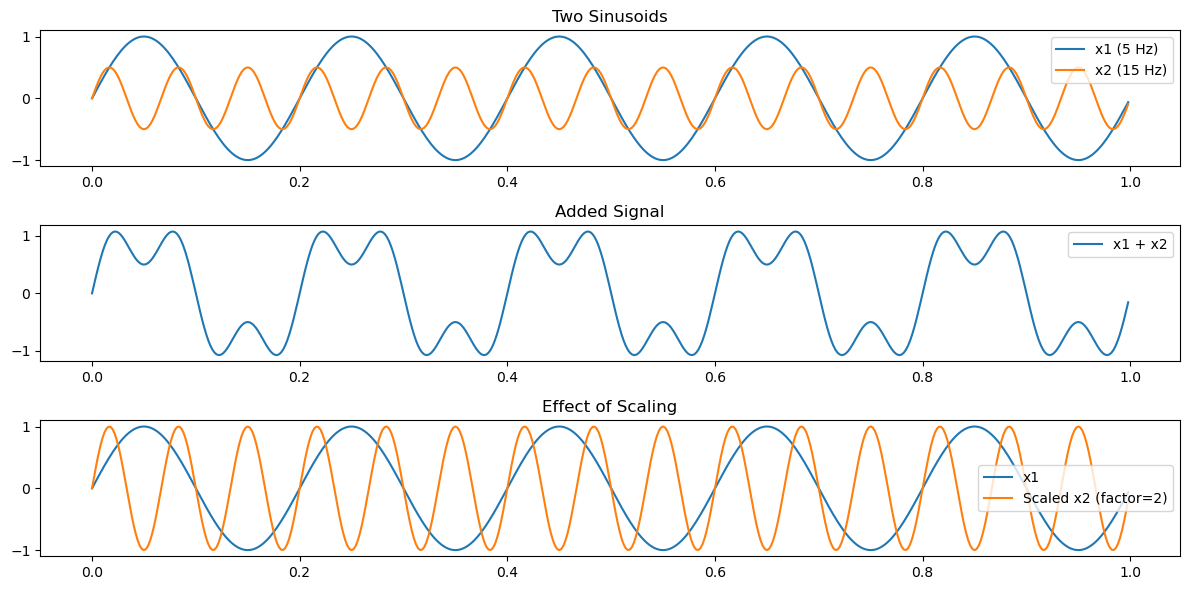

In [36]:
#parameters
fs = 500
t = np.linspace(0, 1, fs, endpoint=False)

#two sinusoids
x1 = 1 * np.sin(2*np.pi*5*t)    #A=1, f=5 Hz
x2 = 0.5 * np.sin(2*np.pi*15*t) #A=0.5, f=15 Hz

#addition
y = x1 + x2

#scaling
x2_scaled = 2 * x2  #amplify second signal

#plot
plt.figure(figsize=(12,6))

plt.subplot(3,1,1)
plt.plot(t, x1, label="x1 (5 Hz)")
plt.plot(t, x2, label="x2 (15 Hz)")
plt.title("Two Sinusoids")
plt.legend()

plt.subplot(3,1,2)
plt.plot(t, y, label="x1 + x2")
plt.title("Added Signal")
plt.legend()

plt.subplot(3,1,3)
plt.plot(t, x1, label="x1")
plt.plot(t, x2_scaled, label="Scaled x2 (factor=2)")
plt.title("Effect of Scaling")
plt.legend()

plt.tight_layout()
plt.show()

## question 6
- generate a clean sinusoidal signal
- add random Gaussian noise to the signal
- apply a low-pass filter and plot the filtered signal

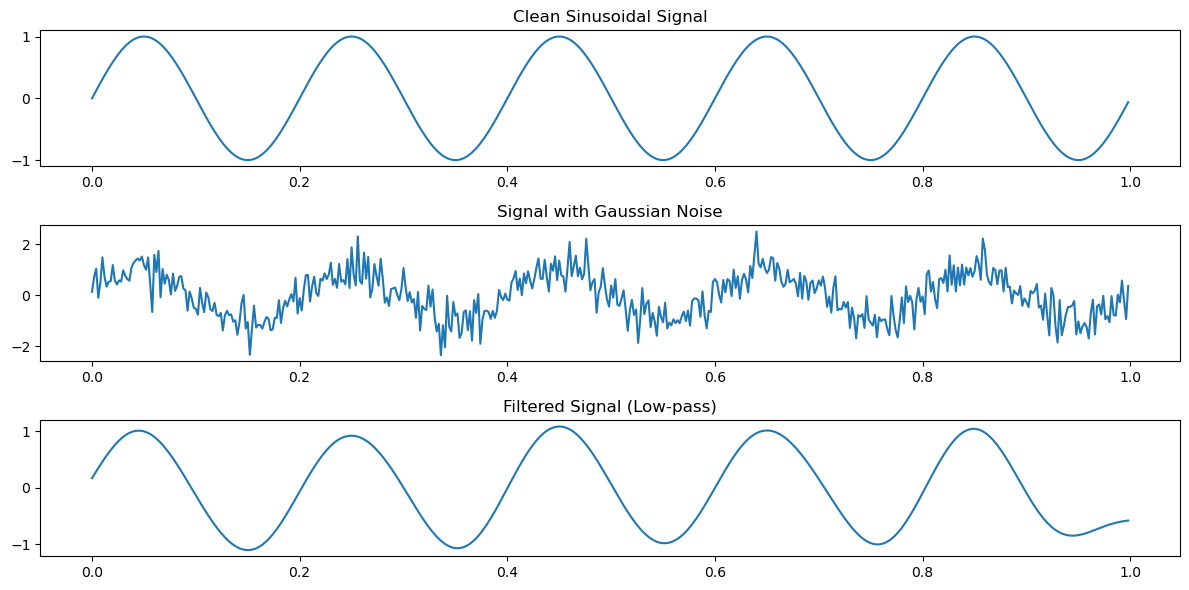

In [38]:
from scipy.signal import butter, filtfilt

#parameters
fs = 500
t = np.linspace(0, 1, fs, endpoint=False)

#clean sinusoid
x = np.sin(2*np.pi*5*t)

#add gaussian noise
noise = np.random.normal(0, 0.5, len(t))
x_noisy = x + noise

#design low-pass butterworth filter
cutoff = 10  # Hz
b, a = butter(6, cutoff/(fs/2), btype='low')
x_filtered = filtfilt(b, a, x_noisy)

#plot
plt.figure(figsize=(12,6))
plt.subplot(3,1,1)
plt.plot(t, x); plt.title("Clean Sinusoidal Signal")

plt.subplot(3,1,2)
plt.plot(t, x_noisy); plt.title("Signal with Gaussian Noise")

plt.subplot(3,1,3)
plt.plot(t, x_filtered); plt.title("Filtered Signal (Low-pass)")
plt.tight_layout()
plt.show()